# Expfit notes 4b: Special forms for multiple exponentials

When fitting more than one exponential, we want to restrict the values parameters can take.

1. With two growing exponentials, one will rapidly make the other unobservable, so beyond the single exponential case we want $c < 0$.
2. For the common use case of bi-exponential decay (or tri-exponential etc.), we want all $b > 0$ or all $b < 0$
3. Another common case is to have $m^+$ rapid exponentials in one direction, followed by $m^-$ slow exponentials in the other (e.g. $b_{i < m^+}>0,\ b_{i \geq m^+} < 0,\ c_i < 0$).

To achieve this without modifying the optimiser, we can use log transformed parameters.

## Restricting $c$

We set $\gamma=\log(-c) \rightarrow c=-e^\gamma$ and redefine the MSE as

\begin{align}
E_m = \frac{1}{n}\sum_{i=1}^n \left( y - a - \sum_{j=1}^m b_j e^{-e^{\gamma_j} x_i} \right)^2
    = \frac{1}{n}\sum_{i=1}^n f^2
\end{align}

For ease of notation, we will still write $c$ instead of $-e^{\gamma}$, but use
\begin{align}
\frac{\partial}{\partial \gamma} c = c
\end{align}

The shorthand becomes
\begin{align}
e_j = e^{c_j x_i} = e^{-e^{\gamma_j} x_i}
\end{align}
with partial derivative
\begin{align}
\frac{\partial}{\partial \gamma_j} e_j = -x e_j e^{\gamma_j} = x e_j c_j
\end{align}
Compared to $\frac{\partial}{\partial c_j} e^{c_j x} = x e^{c_j x}$, this means an extra multiplier $c_j$.

### Jacobian

\begin{align}
\frac{\partial}{\partial a} f &= 1
    & \rightarrow &&
    \frac{\partial E_m}{\partial a} &= \frac{2}{n} \sum_{i=1}^n f \\
\frac{\partial}{\partial b_s} f &= e_s
    & \rightarrow &&
    \frac{\partial E_m}{\partial b_s} &= \frac{2}{n} \sum_{i=1}^n f e_s \\
\frac{\partial}{\partial \gamma_s} f &= b_s c_s x e_s 
    & \rightarrow &&
    \frac{\partial E_m}{\partial \gamma_s} &= \frac{2 b_s c_s}{n} \sum_{i=1}^n f x e_s
\end{align}

### Hessian

For $a$
\begin{align}
\frac{\partial^2 E_m}{\partial a^2} &= 2 \\
\frac{\partial^2 E_m}{\partial b_r\,\partial a} &= \frac{2}{n}\sum_{i=1}^n e_r \\
\frac{\partial^2 E_m}{\partial \gamma_r\,\partial a} &= \frac{2 b_r c_r}{n}\sum_{i=1}^n x e_s
\end{align}

For $b$
\begin{align}
\frac{\partial^2 E_m}{\partial b_r\,\partial b_s} &= \frac{2}{n}\sum_{i=1}^n e_r e_s
\end{align}

For $b$ and $\gamma$
\begin{align}
\frac{\partial^2 E_m}{\partial \gamma_s\,\partial b_s} 
    &= \frac{2 c_s}{n}\sum_{i=1}^n (f + b_s e_s) x e_s \\
r \neq s, \frac{\partial^2 E_m}{\partial \gamma_r\,\partial b_s} 
    &= \frac{2 b_r c_r}{n}\sum_{i=1}^n x e_r e_s
\end{align}

For $\gamma$
\begin{align}
r \neq s, \frac{\partial^2 E_m}{\partial \gamma_r \gamma_s} 
    &= \frac{2 b_r b_s c_r c_s}{n}\sum_{i=1}^n x^2 e_r e_s \\
\frac{\partial^2 E_m}{\partial \gamma_s^2} 
    &= \frac{2 b_s c_s}{n}\sum_{i=1}^n \left( (f + b_se_s) x c_s + f \right) xe_s
\end{align}

The final equation is more complicated than before, as it involves the derivative of $e_s e^{\gamma_s}$, which is a product of two functions of $\gamma_s$.

### Checking against finite differences

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
x = np.linspace(0, 1, 100)

a, b, ct = 5, 5, 0.3
y = a + b * np.exp(-np.exp(ct) * x)

a0, b0, ct0 = a + 1, b - 1, ct + 1

In [3]:
def mse(x, y, p):
    d = len(p)
    assert (d - 1) % 2 == 0 and d > 1
    m = (d - 1) // 2
    p = np.asarray(p)    
    bs = p[1::2].reshape((m, 1))
    cs = -np.exp(p[2::2].reshape((m, 1)))
    return np.sum((p[0] - y + np.sum(bs * np.exp(cs * x), axis=0))**2) / len(x)


def mse_jac_fd(x, y, p, dp):
    e = mse(x, y, p)
    jac = np.zeros(len(p))
    p = np.array(p, dtype=float)
    for i in range(len(p)):
        q = np.copy(p)
        q[i] += dp
        jac[i] = (mse(x, y, q) - e) / dp
    return e, jac
    
    
def mse_jac_hes_fd(x, y, p, dp=1e-5):
    d = len(p)
    m = (d - 1) // 2
    mse, jac = mse_jac_fd(x, y, p, dp)
    
    hes = np.zeros((d, d))
    p = np.array(p, dtype=float)
    for i in range(len(p)):
        q = np.copy(p)
        q[i] += dp
        hes[i] = (mse_jac_fd(x, y, q, dp)[1] - jac) / dp   
    return mse, jac, hes


In [4]:
def mse_jac_hes(x, y, p):
    d = len(p)
    assert (d - 1) % 2 == 0 and d > 1
    m = (d - 1) // 2

    n = len(x)
    ninv2 = 2 / n
    
    # Unpack
    p = np.asarray(p)
    a = p[0]
    b = p[1::2].reshape((m, 1))
    c = -np.exp(p[2::2]).reshape((m, 1))
    
    # MSE
    e = np.exp(c * x)               # (m, n)
    be = b * e                      # (m, n)
    f = a - y + np.sum(be, axis=0)  # (n, )
    mse = np.sum(f**2) / n

    # Jacobian
    ex = e * x       # (m, n)
    bcT = (b * c).T  # (1, m)
    jac = np.zeros(d)
    jac[0] = ninv2 * np.sum(f)
    jac[1::2] = ninv2 * np.sum(f * e, axis=1)
    jac[2::2] = ninv2 * np.sum(f * ex, axis=1) * bcT

    # Hessian
    fbex = (f + be) * x  # (m, n)
    hes = np.zeros((d, d))
    # aa, ab, ac
    hes[0, 0] = 2
    hes[0, 1::2] = hes[1::2, 0] = ninv2 * np.sum(e, axis=1)
    hes[0, 2::2] = hes[2::2, 0] = ninv2 * np.sum(ex, axis=1) * bcT
    for i in range(m):      
        # bi^2, ci^2, and bi*ci
        hes[1 + 2 * i, 1 + 2 * i] = ninv2 * np.sum(e[i]**2)
        hes[2 + 2 * i, 2 + 2 * i] = \
            ninv2 * np.sum((fbex[i] * c[i, 0] + f) * ex[i]) * bcT[0, i]
        hes[1 + 2 * i, 2 + 2 * i] = hes[2 + 2 * i, 1 + 2 * i] = \
            ninv2 * np.sum(fbex[i] * e[i]) * c[i, 0]
        for j in range(i + 1, m):
            eij = e[i] * e[j]
            eijx = eij * x
            # bi*bj, ci*cj, bi*cj, bj*ci
            hes[1 + 2 * i, 1 + 2 * j] = hes[1 + 2 * j, 1 + 2 * i] = \
                ninv2 * np.sum(eij)
            hes[2 + 2 * i, 2 + 2 * j] = hes[2 + 2 * j, 2 + 2 * i] = \
                ninv2 * np.sum(eijx * x) * bcT[0, i] * bcT[0, j]
            hes[1 + 2 * i, 2 + 2 * j] = hes[2 + 2 * j, 1 + 2 * i] = \
                ninv2 * np.sum(eijx) * bcT[0, j]
            hes[2 + 2 * i, 1 + 2 * j] = hes[1 + 2 * j, 2 + 2 * i] = \
                ninv2 * np.sum(eijx) * bcT[0, i]

    return mse, jac, hes


m1, j1, h1 = mse_jac_hes(x, y, (a0, b0, ct0, 3, -7, 1.1, 2.2))
m2, j2, h2 = mse_jac_hes_fd(x, y, (a0, b0, ct0, 3, -7, 1.1, 2.2))
print(m1)
print(m2)
print()
with np.printoptions(linewidth=120):
    print(j1)
    print(j2)
    print()
    print(h1)
    print(h2)
    print()
    print(np.abs(h1 - h2) < 1e-4)
    print()
    print(np.max(np.abs(h1 - h2)))

6.180662833781528
6.180662833781528

[ 4.89883194  1.43602515 -4.41990583  4.89663664 -0.00658384  0.70968099 -0.60486045]
[ 4.89884194  1.43602655 -4.41988182  4.89664663 -0.00658387  0.70968159 -0.60485768]

[[ 2.00000000e+00  5.36170985e-01 -1.90498574e+00  1.99908840e+00 -2.73397501e-03  2.29516948e-01 -2.40882813e-01]
 [ 5.36170985e-01  2.79761064e-01 -1.64151218e+00  5.36052654e-01 -3.54923324e-04  1.66188593e-01 -1.21807870e-01]
 [-1.90498574e+00 -1.64151218e+00  4.80055475e+00 -1.90422155e+00  2.29197076e-03 -1.80085034e-01  2.81988802e-01]
 [ 1.99908840e+00  5.36052654e-01 -1.90422155e+00  1.99817735e+00 -4.92691810e-03  2.29494824e-01 -2.40834339e-01]
 [-2.73397501e-03 -3.54923324e-04  2.29197076e-03 -4.92691810e-03 -6.57470228e-03 -6.63647935e-05  1.45397740e-04]
 [ 2.29516948e-01  1.66188593e-01 -1.80085034e-01  2.29494824e-01 -6.63647935e-05  1.19998830e-01 -6.10038591e-01]
 [-2.40882813e-01 -1.21807870e-01  2.81988802e-01 -2.40834339e-01  1.45397740e-04 -6.10038591e-01  5

## Restricting $c$ and $b$

Next, we add similar restrictions on $b$, by writing $b_j = z_j e^{\beta}$, where $z_j \in \{-1, 1\}$ is a constant determining the sign of $b$.

This gives us the MSE
\begin{align}
E_m = \frac{1}{n}\sum_{i=1}^n \left( y - a - \sum_{j=1}^m z_j e^{\beta_j} e^{-e^{\gamma_j} x_i} \right)^2
    = \frac{1}{n}\sum_{i=1}^n \left( y - a - \sum_{j=1}^m b_j e_j \right)^2
    = \frac{1}{n}\sum_{i=1}^n f^2
\end{align}

As before, we still write $b_j = z_j e^{\beta_j}$, but use
\begin{align}
\frac{\partial}{\partial \beta} b = z_j e^{\beta_j} = b
\qquad\qquad
\frac{\partial}{\partial \gamma} c = c
\qquad\qquad
\frac{\partial}{\partial \gamma_j} e_j = x e_j c_j
\end{align}

### Jacobian

\begin{align}
\frac{\partial}{\partial a} f &= 1
    & \rightarrow &&
    \frac{\partial E_m}{\partial a} &= \frac{2}{n} \sum_{i=1}^n f \\
\frac{\partial}{\partial \beta_s} f &= b_s e_s
    & \rightarrow && \frac{\partial E_m}{\partial \beta_s} 
        &= \frac{2 b_s}{n} \sum_{i=1}^n f e_s \\
\frac{\partial}{\partial \gamma_s} f &= b_s c_s x e_s
    & \rightarrow &&
    \frac{\partial E_m}{\partial \gamma_s} 
        &= \frac{2 b_s c_s}{n} \sum_{i=1}^n f x e_s
\end{align}

### Hessian

For a
\begin{align}
\frac{\partial^2 E_m}{\partial a^2} &= 2 \\
\frac{\partial^2 E_m}{\partial \beta_r\,\partial a} &= \frac{2 b_r}{n}\sum^n e_r \\
\frac{\partial^2 E_m}{\partial \gamma_r\,\partial a} &= \frac{2 b_r c_r}{n}\sum^n x e_r
\end{align}

For $\beta$
\begin{align}
\frac{\partial^2 E_m}{\partial \beta_s\,\partial \beta_s} 
    &= \frac{2 b_s}{n}\sum_{i=1}^n e_s (f + b_s e_s)  \\
r \neq s, \frac{\partial^2 E_m}{\partial \beta_r\,\partial \beta_s} 
    &= \frac{2 b_r b_s}{n}\sum_{i=1}^n e_r e_s
\end{align}

For $\beta$ and $\gamma$
\begin{align}
\frac{\partial^2 E_m}{\partial \gamma_s\,\partial \beta_s} 
    &= \frac{2 b_s c_s}{n}\sum_{i=1}^n (f + b_s e_s) x e_s \\
r \neq s, \frac{\partial^2 E_m}{\partial \gamma_r\,\partial \beta_s} 
    &= \frac{2 b_r b_s c_r}{n} \sum_{i=1}^n x e_r e_s
\end{align}

For $\gamma$
\begin{align}
r \neq s, \frac{\partial^2 E_m}{\partial \gamma_r \gamma_s} 
    &= \frac{2 b_r b_s c_r c_s}{n}\sum_{i=1}^n x^2 e_r e_s \\
\frac{\partial^2 E_m}{\partial \gamma_s^2} 
    &= \frac{2 b_s c_s}{n}\sum_{i=1}^n \left( (f + b_s e_s) x c_s + f \right)xe_s
\end{align}

### Checking against finite differences

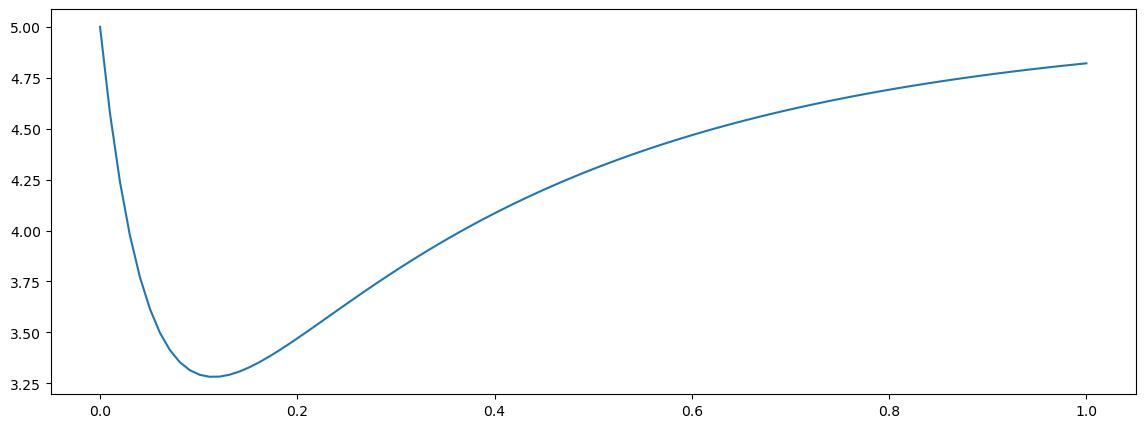

In [5]:
x = np.linspace(0, 1, 100)

a, bt1, ct1, bt2, ct2 = 5, 1, 1, 1, 3
z = np.array([-1, 1])
y = a + z[0] * np.exp(bt1) * np.exp(-np.exp(ct1) * x) + z[1] * np.exp(bt2) * np.exp(-np.exp(ct2) * x)

a0, bt10, ct10, bt20, ct20 = a - 1, bt1 + 1, ct1 + 1, bt2 + 1, ct1 + 2

import matplotlib.pyplot as plt
fig = plt.figure(figsize=(14, 5))
ax = fig.add_subplot()
ax.plot(x, y)
plt.show()

In [6]:
def mse(x, y, p):
    d = len(p)
    assert (d - 1) % 2 == 0 and d > 1
    m = (d - 1) // 2
    p = np.asarray(p)    
    b = (z * np.exp(p[1::2])).reshape((m, 1))
    c = -np.exp(p[2::2].reshape((m, 1)))
    return np.sum((p[0] - y + np.sum(b * np.exp(c * x), axis=0))**2) / len(x)


def mse_jac_fd(x, y, p, dp):
    e = mse(x, y, p)
    jac = np.zeros(len(p))
    p = np.array(p, dtype=float)
    for i in range(len(p)):
        q = np.copy(p)
        q[i] += dp
        jac[i] = (mse(x, y, q) - e) / dp
    return e, jac
    
    
def mse_jac_hes_fd(x, y, p, dp=1e-5):
    d = len(p)
    m = (d - 1) // 2
    mse, jac = mse_jac_fd(x, y, p, dp)
    
    hes = np.zeros((d, d))
    p = np.array(p, dtype=float)
    for i in range(len(p)):
        q = np.copy(p)
        q[i] += dp
        hes[i] = (mse_jac_fd(x, y, q, dp)[1] - jac) / dp   
    return mse, jac, hes

print(mse(x, y, [a, bt1, ct1, bt2, ct2]))

1.0593385066107551e-31


In [7]:
def mse_jac_hes(x, y, p):
    d = len(p)
    assert (d - 1) % 2 == 0 and d > 1
    m = (d - 1) // 2

    n = len(x)
    ninv2 = 2 / n
    
    # Unpack
    p = np.asarray(p)
    a = p[0]
    b = (z * np.exp(p[1::2])).reshape((m, 1))  # (m, 1)
    c = -np.exp(p[2::2]).reshape((m, 1))       # (m, 1)
    
    # MSE
    e = np.exp(c * x)               # (m, n)
    be = b * e                      # (m, n)
    f = a - y + np.sum(be, axis=0)  # (n, )
    mse = np.sum(f**2) / n

    # Jacobian
    ex = e * x
    bcT = (b * c).T
    jac = np.zeros(d)
    jac[0] = ninv2 * np.sum(f)
    jac[1::2] = ninv2 * np.sum(f * e, axis=1) * b.T
    jac[2::2] = ninv2 * np.sum(f * ex, axis=1) * bcT

    # Hessian
    fbe = f + be    # (m, n)
    fbex = fbe * x  # (m, n)
    # aa, ab, ac
    hes = np.zeros((d, d))
    hes[0, 0] = 2
    hes[0, 1::2] = hes[1::2, 0] = ninv2 * np.sum(e, axis=1) * b.T
    hes[0, 2::2] = hes[2::2, 0] = ninv2 * np.sum(ex, axis=1) * bcT
    for i in range(m):
        # bi^2, ci^2, and bi*ci
        hes[1 + 2 * i, 1 + 2 * i] = \
            ninv2 * np.sum(fbe[i] * e[i]) * b[i, 0]
        hes[2 + 2 * i, 2 + 2 * i] = \
            ninv2 * np.sum((fbex[i] * c[i, 0] + f) * ex[i]) * bcT[0, i]
        hes[1 + 2 * i, 2 + 2 * i] = hes[2 + 2 * i, 1 + 2 * i] = \
            ninv2 * np.sum(fbex[i] * e[i]) * bcT[0, i]
        for j in range(i + 1, m):
            eij = e[i] * e[j]
            eijx = eij * x
            seijx = np.sum(eijx)
            # bi*bj, ci*cj, bi*cj, bj*ci
            hes[1 + 2 * i, 1 + 2 * j] = hes[1 + 2 * j, 1 + 2 * i] = \
                ninv2 * np.sum(eij) * b[i, 0] * b[j, 0]
            hes[2 + 2 * i, 2 + 2 * j] = hes[2 + 2 * j, 2 + 2 * i] = \
                ninv2 * np.sum(eijx * x) * bcT[0, i] * bcT[0, j]
            hes[1 + 2 * i, 2 + 2 * j] = hes[2 + 2 * j, 1 + 2 * i] = \
                ninv2 * seijx * bcT[0, j] * b[i, 0]
            hes[2 + 2 * i, 1 + 2 * j] = hes[1 + 2 * j, 2 + 2 * i] = \
                ninv2 * seijx * bcT[0, i] * b[j, 0]

    return mse, jac, hes


m1, j1, h1 = mse_jac_hes(x, y, (a0, bt10, ct10, bt20, ct20))
m2, j2, h2 = mse_jac_hes_fd(x, y, (a0, bt10, ct10, bt20, ct20))
print(m1)
print(m2)
print()
with np.printoptions(linewidth=120):
    print(j1)
    print(j2)
    print()
    print(np.abs(h1 - h2) < 5e-4)
    print()
    print(np.max(np.abs(h1 - h2)))
    print()
    print(h1)

0.8821951945482002
0.8821951945482002

[-1.66647123  2.94125687 -2.08253495 -1.2886542   1.21572257]
[-1.66646123  2.94131095 -2.08251219 -1.28864428  1.21572485]

[[ True  True  True  True  True]
 [ True  True  True  True  True]
 [ True  True  True  True  True]
 [ True  True  True  True  True]
 [ True  True  True  True  True]]

0.00026594246965139234

[[ 2.         -2.05363113  1.96915004  0.80478868 -0.72590786]
 [-2.05363113 10.81597973 -5.73331302 -4.50590475  2.85810672]
 [ 1.96915004 -5.73331302  4.55208457  1.0514387  -1.54718074]
 [ 0.80478868 -4.50590475  1.0514387   1.98524905 -0.11151609]
 [-0.72590786  2.85810672 -1.54718074 -0.11151609  0.45504876]]


## Tau form

Finally, to draw confidence intervals, we add an error in tau form.

As before
\begin{align}
E_m = \frac{1}{n}\sum_{i=1}^n \left( a - y + \sum_{j=1}^m b_j e^{-x_i / \tau_j} \right)^2
    = \frac{1}{n}\sum_{i=1}^n \left( a - y + \sum_{j=1}^m b_j e_j \right)^2
    = \frac{1}{n}\sum_{i=1}^n f^2
\end{align}
but now
\begin{align}
\frac{\partial}{\partial \tau_j} c = c^2
\qquad\qquad
\frac{\partial}{\partial \tau_j} e_j = x\tau^{-2}e_j = xc^2e_j
\qquad\qquad
\frac{\partial}{\partial \tau_s} f &= b_s c_s^2 x e_s
\end{align}

This changes the c-entries in the Jacobian to
\begin{align}
\frac{\partial E_m}{\partial \tau_s} = \frac{2b_sc_s^2}{n} \sum_{i=1}^n f x e_s
\end{align}

and for the Hessian

\begin{align}
\frac{\partial^2 E_m}{\partial \tau_r\,\partial a} &= \frac{2 b_r c_r^2}{n}\sum^n_{i=1} xe_r
\end{align}

\begin{align}
\frac{\partial^2 E_m}{\partial \tau_s\,\partial b_s}
    &= \frac{2c_s^2}{n}\sum_{i=1}^n (f + b_s e_s) xe_s \\
r \neq s, \frac{\partial^2 E_m}{\partial \tau_r\,\partial b_s} 
    &= \frac{2 b_r c_r^2}{n}\sum_{i=1}^n x e_r e_s
\end{align}

\begin{align}
r \neq s, \frac{\partial^2 E_m}{\partial \tau_r \tau_s} 
    &= \frac{2 b_r b_s c_r^2 c_s^3}{n}\sum_{i=1}^n x^2 e_r e_s \\
\frac{\partial^2 E_m}{\partial \tau_s^2} 
    &= \frac{2 b_s c_s^2}{n}\sum_{i=1}^n \left( (f + b_s e_s) c_s x + 2 f \right) x e_s
\end{align}


### Finite differences

In [8]:
x = np.linspace(0, 1, 100)
a, b1, tau1, b2, tau2 = 4, 1, 0.5, 2, 0.9
y = a + b1 * np.exp(-x / tau1) + b2 * np.exp(-x / tau2)

a0, b10, tau10, b20, tau20 = a + 1, b1 - 0.5, tau1 - 0.3, b2 - 1, tau2 + 0.5

In [9]:
def mse(x, y, p):
    d = len(p)
    assert (d - 1) % 2 == 0 and d > 1
    m = (d - 1) // 2
    p = np.asarray(p)    
    b = p[1::2].reshape((m, 1))
    c = -1 / p[2::2].reshape((m, 1))
    return np.sum((p[0] - y + np.sum(b * np.exp(c * x), axis=0))**2) / len(x)


def mse_jac_fd(x, y, p, dp):
    e = mse(x, y, p)
    jac = np.zeros(len(p))
    p = np.array(p, dtype=float)
    for i in range(len(p)):
        q = np.copy(p)
        q[i] += dp
        jac[i] = (mse(x, y, q) - e) / dp
    return e, jac
    
    
def mse_jac_hes_fd(x, y, p, dp=1e-5):
    d = len(p)
    m = (d - 1) // 2
    mse, jac = mse_jac_fd(x, y, p, dp)
    
    hes = np.zeros((d, d))
    p = np.array(p, dtype=float)
    for i in range(len(p)):
        q = np.copy(p)
        q[i] += dp
        hes[i] = (mse_jac_fd(x, y, q, dp)[1] - jac) / dp   
    return mse, jac, hes

print(mse(x, y, [a, b1, tau1, b2, tau2]))

1.0514036752398797e-31


In [13]:
def mse_jac_hes(x, y, p):
    d = len(p)
    assert (d - 1) % 2 == 0 and d > 1
    m = (d - 1) // 2

    n = len(x)
    ninv2 = 2 / n
    
    # Unpack
    p = np.asarray(p)
    a = p[0]
    b = p[1::2].reshape((m, 1))       # (m, 1)
    c = -1 / p[2::2].reshape((m, 1))  # (m, 1)

    # MSE
    e = np.exp(c * x)               # (m, n)  e^(cx)
    be = b * e                      # (m, n) be^(cx)
    f = a - y + np.sum(be, axis=0)  # (n, ) a - y + sum_j(be^(cx))
    mse = np.sum(f**2) / n

    # Jacobian
    c2 = c * c
    bc2 = b * c2
    ex = e * x
    jac = np.zeros(d)
    jac[0] = ninv2 * np.sum(f)
    jac[1::2] = ninv2 * np.sum(f * e, axis=1)
    jac[2::2] = ninv2 * np.sum(f * ex, axis=1) * bc2.T

    # Hessian
    fbe = f + be    # (m, n)
    fbex = fbe * x  # (m, n)
    # aa, ab, ac
    hes = np.zeros((d, d))
    hes[0, 0] = 2
    hes[0, 1::2] = hes[1::2, 0] = ninv2 * np.sum(e, axis=1)
    hes[0, 2::2] = hes[2::2, 0] = ninv2 * np.sum(ex, axis=1) * bc2.T
    for i in range(m):
        # bi^2, ci^2, and bi*ci
        hes[1 + 2 * i, 1 + 2 * i] = ninv2 * np.sum(e[i]**2)
        hes[2 + 2 * i, 2 + 2 * i] = \
            ninv2 * np.sum((fbex[i] * c[i, 0] + 2 * f) * ex[i]) * bc2[i, 0] * c[i, 0]
        hes[1 + 2 * i, 2 + 2 * i] = hes[2 + 2 * i, 1 + 2 * i] = \
            ninv2 * np.sum(fbex[i]* e[i]) * c2[i, 0]
        for j in range(i + 1, m):
            eij = e[i] * e[j]
            eijx = eij * x
            seijx = np.sum(eijx)
            # bi*bj, ci*cj, bi*cj, bj*ci
            hes[1 + 2 * i, 1 + 2 * j] = hes[1 + 2 * j, 1 + 2 * i] = \
                ninv2 * np.sum(eij)
            hes[2 + 2 * i, 2 + 2 * j] = hes[2 + 2 * j, 2 + 2 * i] = \
                ninv2 * np.sum(eijx * x) * bc2[i, 0] * bc2[j, 0]
            hes[1 + 2 * i, 2 + 2 * j] = hes[2 + 2 * j, 1 + 2 * i] = \
                ninv2 * seijx * bc2[j, 0]
            hes[2 + 2 * i, 1 + 2 * j] = hes[1 + 2 * j, 2 + 2 * i] = \
                ninv2 * seijx * bc2[i, 0]

    return mse, jac, hes


m1, j1, h1 = mse_jac_hes_fd(x, y, (a0, b10, tau10, b20, tau20))
m2, j2, h2 = mse_jac_hes(x, y, (a0, b10, tau10, b20, tau20))
print(m1)
print(m2)
print()
with np.printoptions(linewidth=120):
    print(j1)
    print(j2)
    print()
    print(np.abs(h1 - h2) < 5e-4)
    print()
    print(np.max(np.abs(h1 - h2)))
    print()
    print(h1)
    print()
    print(h2)

0.16543502878649816
0.16543502878649816

[ 0.34687777 -0.09648877  0.00958348  0.1389887   0.10849845]
[ 0.34686777 -0.09648982  0.00957237  0.13898337  0.10849868]

[[ True  True  True  True  True]
 [ True  True  True  True  True]
 [ True  True  True  True  True]
 [ True  True  True  True  True]
 [ True  True  True  True  True]]

0.00018447145342515014

[[ 1.99999989  0.4034828   0.95059877  1.42989204  0.32084391]
 [ 0.4034828   0.20816071  0.26634389  0.35548647  0.03025996]
 [ 0.95059877  0.26634389  2.22166424  0.74137446  0.12527396]
 [ 1.42989204  0.35548647  0.74137446  1.06625875  0.3166184 ]
 [ 0.32084391  0.03025996  0.12527396  0.3166184  -0.04662021]]

[[ 2.          0.40348276  0.95060276  1.42989207  0.32084601]
 [ 0.40348276  0.20815978  0.2663164   0.35548593  0.03026043]
 [ 0.95060276  0.2663164   2.22184871  0.74138057  0.12527385]
 [ 1.42989207  0.35548593  0.74138057  1.06625846  0.31661714]
 [ 0.32084601  0.03026043  0.12527385  0.31661714 -0.04661942]]
